**Exercise 1 : Comparative Analysis of Structured and Unstructured Data**

In [1]:
# Analyse des Données Structurées (Ventes)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- Analyse des Données Structurées (Ventes) ---")

--- Analyse des Données Structurées (Ventes) ---


In [2]:
# 1. Chargement du dataset de ventes
print("\n1. Chargement du dataset 'statsfinal.csv'...")
try:
    # Le fichier 'statsfinal.csv' semble contenir une colonne d'index non nommée.
    # On spécifie index_col=0 pour la traiter comme l'index.
    sales_df = pd.read_csv('/content/statsfinal.csv', index_col=0)
    print("Dataset 'statsfinal.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'statsfinal.csv' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est dans le même répertoire.")
    exit()


1. Chargement du dataset 'statsfinal.csv'...
Dataset 'statsfinal.csv' chargé avec succès.


In [4]:
# 2. Inspection des Données
print("\n2. Inspection des Données (head, info, nulls)...")
print("\nSales DataFrame Head:")
print(sales_df.head())

print("\nSales DataFrame Info:")
sales_df.info()

print("\nSales DataFrame Nulls:")
print(sales_df.isnull().sum())

# Convertir la colonne 'Date' en format datetime
# Added errors='coerce' to handle invalid date values by converting them to NaT
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d-%m-%Y', errors='coerce')
print("\nColonne 'Date' convertie en datetime.")


2. Inspection des Données (head, info, nulls)...

Sales DataFrame Head:
         Date  Q-P1  Q-P2  Q-P3  Q-P4      S-P1      S-P2      S-P3      S-P4
0  13-06-2010  5422  3725   576   907  17187.74  23616.50   3121.92   6466.91
1  14-06-2010  7047   779  3578  1574  22338.99   4938.86  19392.76  11222.62
2  15-06-2010  1572  2082   595  1145   4983.24  13199.88   3224.90   8163.85
3  16-06-2010  5657  2399  3140  1672  17932.69  15209.66  17018.80  11921.36
4  17-06-2010  3668  3207  2184   708  11627.56  20332.38  11837.28   5048.04

Sales DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4600 entries, 0 to 4599
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4600 non-null   object 
 1   Q-P1    4600 non-null   int64  
 2   Q-P2    4600 non-null   int64  
 3   Q-P3    4600 non-null   int64  
 4   Q-P4    4600 non-null   int64  
 5   S-P1    4600 non-null   float64
 6   S-P2    4600 non-null   float64
 7


3. Analyse Exploratoire de Base...

Tendances des ventes (S-P1, S-P2, S-P3, S-P4) au fil du temps:


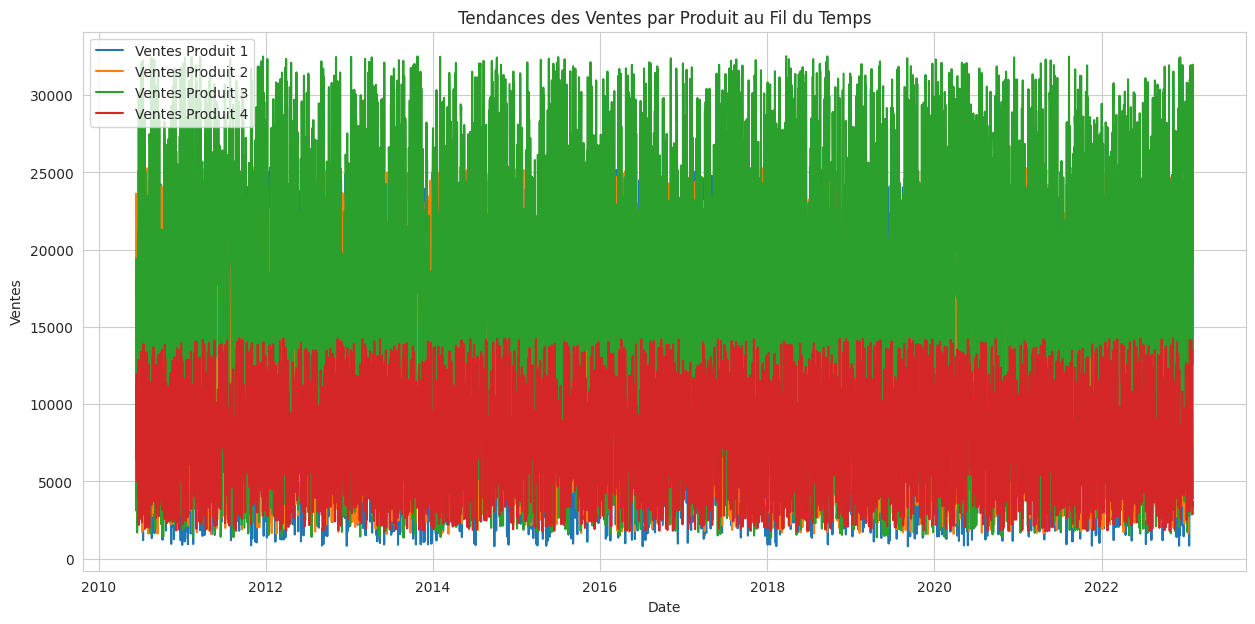

Insight: Les ventes de chaque produit montrent des fluctuations au fil du temps, avec des pics et des creux.
Certains produits (ex: S-P1, S-P2) ont des volumes de ventes plus élevés que d'autres (ex: S-P3, S-P4).

Matrice de corrélation des ventes de produits:


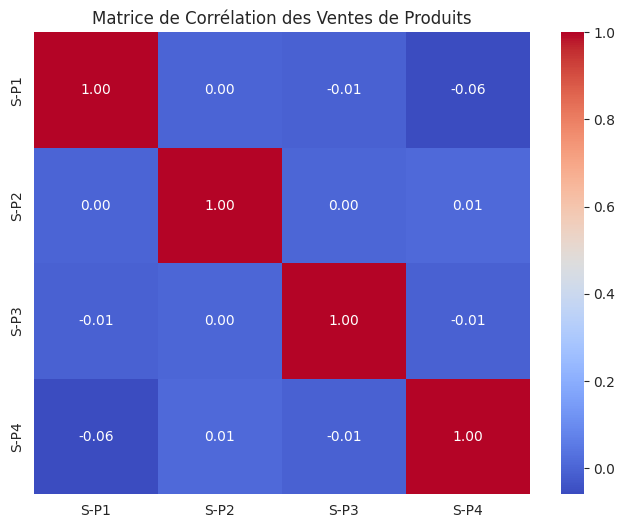

Insight: Il y a des corrélations positives entre les ventes de certains produits, suggérant des dynamiques de marché liées.

Distributions des quantités vendues par produit:


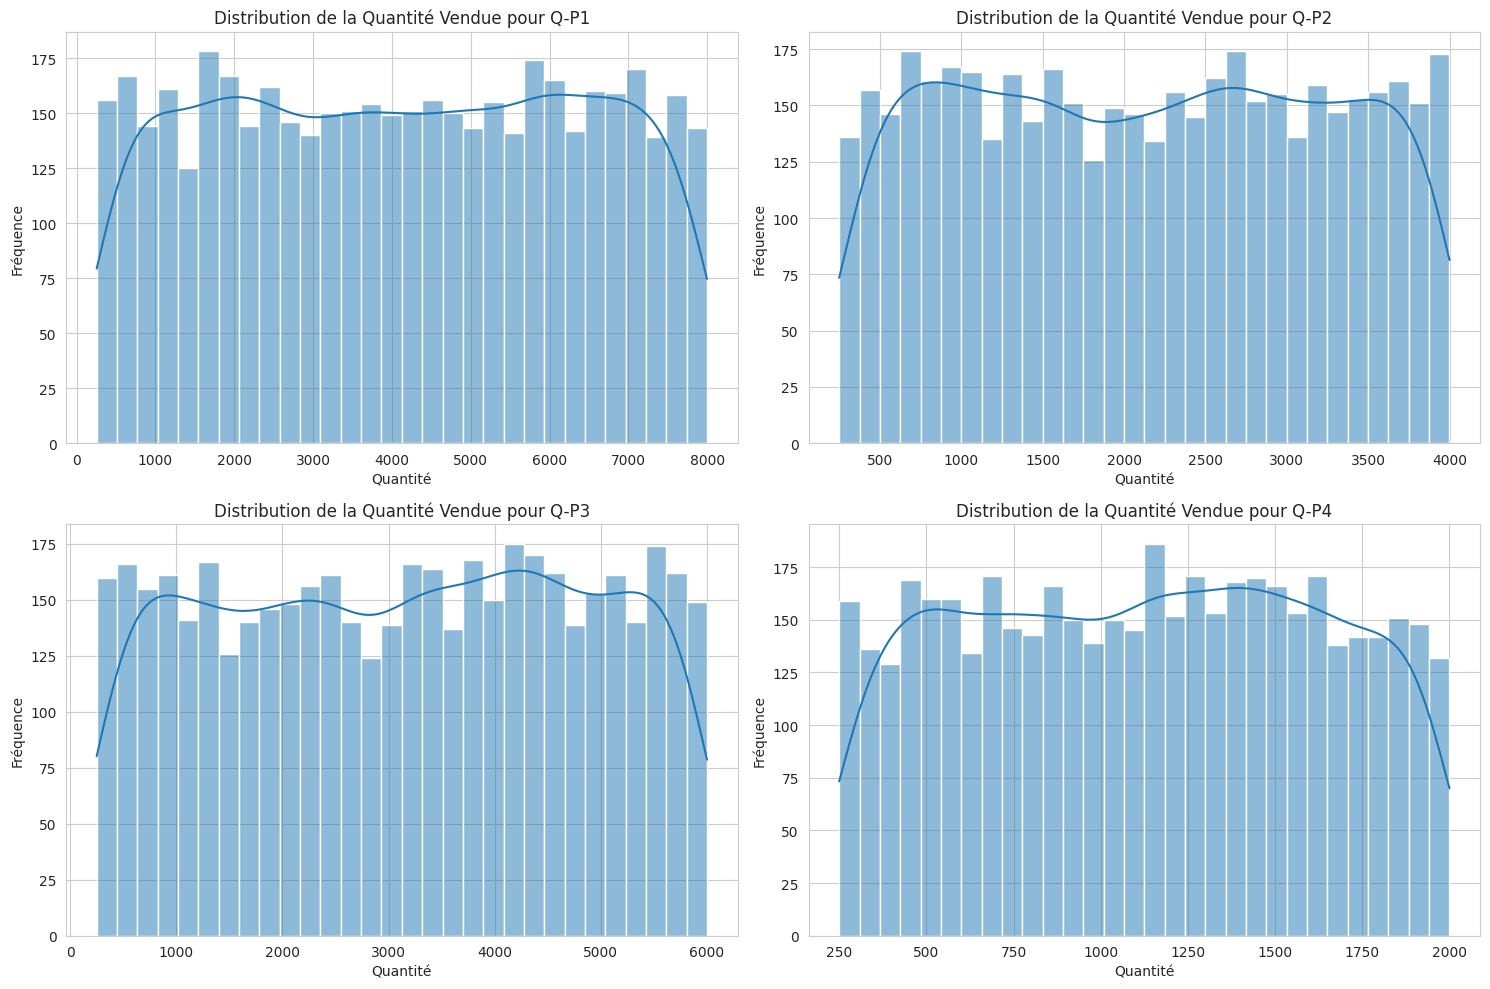

Insight: Les distributions des quantités varient par produit, certains ayant des ventes plus concentrées à des niveaux bas, d'autres plus étalées.

Analyse des données structurées terminée.


In [5]:
# 3. Analyse Exploratoire de Base
print("\n3. Analyse Exploratoire de Base...")

# Tendances des ventes par produit au fil du temps
print("\nTendances des ventes (S-P1, S-P2, S-P3, S-P4) au fil du temps:")
plt.figure(figsize=(15, 7))
plt.plot(sales_df['Date'], sales_df['S-P1'], label='Ventes Produit 1')
plt.plot(sales_df['Date'], sales_df['S-P2'], label='Ventes Produit 2')
plt.plot(sales_df['Date'], sales_df['S-P3'], label='Ventes Produit 3')
plt.plot(sales_df['Date'], sales_df['S-P4'], label='Ventes Produit 4')
plt.title('Tendances des Ventes par Produit au Fil du Temps')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.legend()
plt.grid(True)
plt.show()
print("Insight: Les ventes de chaque produit montrent des fluctuations au fil du temps, avec des pics et des creux.")
print("Certains produits (ex: S-P1, S-P2) ont des volumes de ventes plus élevés que d'autres (ex: S-P3, S-P4).")

# Corrélation entre les ventes des différents produits
print("\nMatrice de corrélation des ventes de produits:")
sales_cols = ['S-P1', 'S-P2', 'S-P3', 'S-P4']
correlation_matrix = sales_df[sales_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Ventes de Produits')
plt.show()
print("Insight: Il y a des corrélations positives entre les ventes de certains produits, suggérant des dynamiques de marché liées.")

# Distribution des quantités vendues (Q-P1, Q-P2, Q-P3, Q-P4)
print("\nDistributions des quantités vendues par produit:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Q-P1', 'Q-P2', 'Q-P3', 'Q-P4']):
    plt.subplot(2, 2, i + 1)
    sns.histplot(sales_df[col], bins=30, kde=True)
    plt.title(f'Distribution de la Quantité Vendue pour {col}')
    plt.xlabel('Quantité')
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()
print("Insight: Les distributions des quantités varient par produit, certains ayant des ventes plus concentrées à des niveaux bas, d'autres plus étalées.")

print("\nAnalyse des données structurées terminée.")

**Analyse des Données Non Structurées (Tickets Support Client)**


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re # Pour le nettoyage de texte

In [7]:
try:
    from textblob import TextBlob
except ImportError:
    print("TextBlob library not found. Installing now...")
    !pip install -q textblob
    from textblob import TextBlob
    # Télécharger les corpora nécessaires pour TextBlob (peut prendre un moment)
    print("Downloading TextBlob corpora. This might take a moment...")
    !python -m textblob.download_corpora
    print("TextBlob corpora download complete.")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

print("\n--- Analyse des Données Non Structurées (Tickets Support Client) ---")


--- Analyse des Données Non Structurées (Tickets Support Client) ---


In [8]:
# 1. Chargement du dataset de tickets support
print("\n1. Chargement du dataset 'customer_support_tickets.csv'...")
try:
    # Le fichier peut avoir une colonne d'index non nommée.
    tickets_df = pd.read_csv('/content/customer_support_tickets.csv', index_col=0)
    print("Dataset 'customer_support_tickets.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'customer_support_tickets.csv' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est dans le même répertoire.")
    exit()


1. Chargement du dataset 'customer_support_tickets.csv'...
Dataset 'customer_support_tickets.csv' chargé avec succès.


In [9]:
# 2. Inspection des Données
print("\n2. Inspection des Données (head, info, nulls)...")
print("\nTickets DataFrame Head:")
print(tickets_df.head())

print("\nTickets DataFrame Info:")
tickets_df.info()

print("\nTickets DataFrame Nulls:")
print(tickets_df.isnull().sum())


2. Inspection des Données (head, info, nulls)...

Tickets DataFrame Head:
                 Customer Name              Customer Email  Customer Age  \
Ticket ID                                                                  
1                Marisa Obrien  carrollallison@example.com            32   
2                 Jessica Rios    clarkeashley@example.com            42   
3          Christopher Robbins   gonzalestracy@example.com            48   
4             Christina Dillon    bradleyolson@example.org            27   
5            Alexander Carroll     bradleymark@example.com            67   

          Customer Gender Product Purchased Date of Purchase      Ticket Type  \
Ticket ID                                                                       
1                   Other        GoPro Hero       2021-03-22  Technical issue   
2                  Female       LG Smart TV       2021-05-22  Technical issue   
3                   Other          Dell XPS       2020-07-14  Techni

In [11]:
# 3. Nettoyage des Données
print("\n3. Nettoyage des Données...")

# Remplir les valeurs manquantes dans 'Ticket Description' avec une chaîne vide
tickets_df['Ticket Description'] = tickets_df['Ticket Description'].fillna('')
# Remplir les valeurs manquantes dans 'Resolution' avec une chaîne vide
tickets_df['Resolution'] = tickets_df['Resolution'].fillna('')
# Pour 'Customer Satisfaction Rating', on peut le remplir avec une valeur neutre ou la médiane si on l'utilise numériquement
# Pour l'instant, nous allons nous concentrer sur le texte.

print("\nValeurs manquantes après nettoyage initial:")
print(tickets_df.isnull().sum())


3. Nettoyage des Données...

Valeurs manquantes après nettoyage initial:
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64



4. Analyse Exploratoire de Base et Sentiment Analysis...

Distribution des types de tickets:


/tmp/ipython-input-12-532749441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Ticket Type', data=tickets_df, order=tickets_df['Ticket Type'].value_counts().index, palette='viridis')


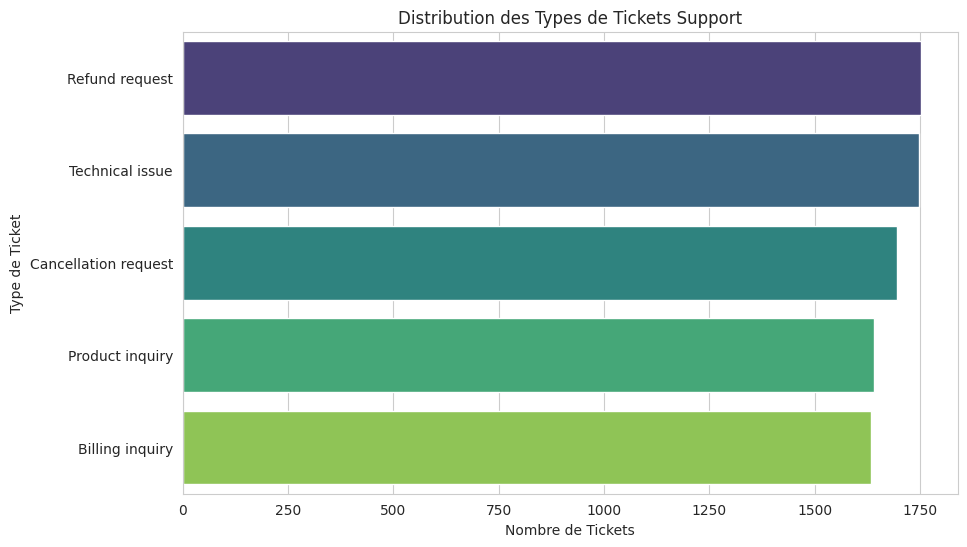

Insight: 'Technical issue' et 'Product inquiry' sont les types de tickets les plus fréquents.

Distribution des sujets de tickets (Top 10):


/tmp/ipython-input-12-532749441.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Ticket Subject', data=tickets_df, order=tickets_df['Ticket Subject'].value_counts().nlargest(10).index, palette='plasma')


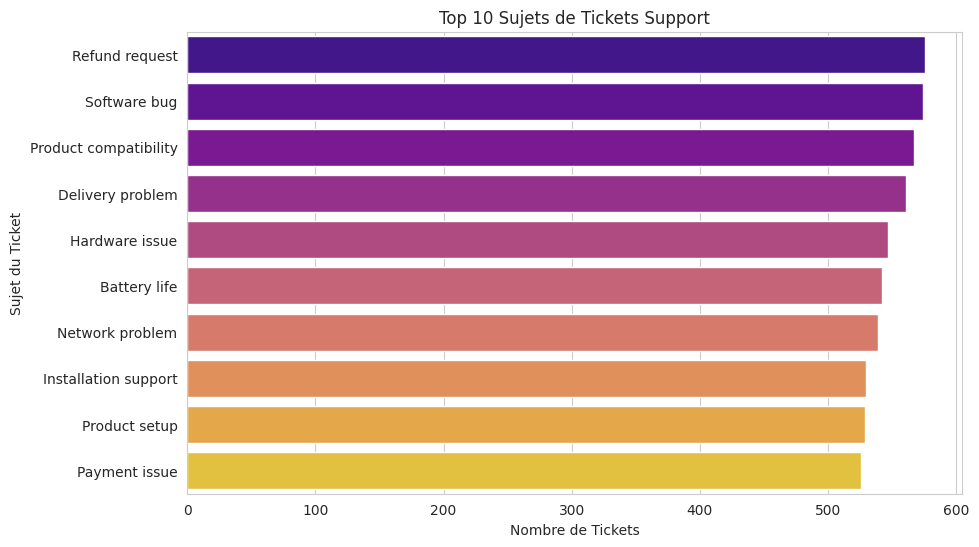

Insight: 'Account access', 'Product setup', 'Network problem' sont les sujets récurrents.

Distribution de la polarité de sentiment des descriptions de tickets:


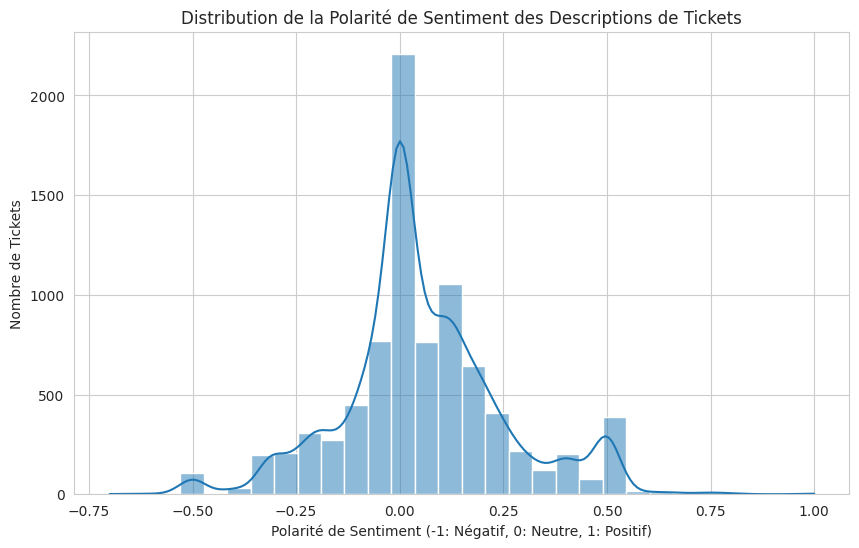

Insight: La distribution de sentiment est centrée autour de 0, indiquant une majorité de descriptions neutres.
Cependant, il y a des queues vers les sentiments négatifs, ce qui est attendu pour des tickets de support.

Distribution des catégories de sentiment:


/tmp/ipython-input-12-532749441.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Category', data=tickets_df, order=['Negative', 'Neutral', 'Positive'], palette='RdYlGn')


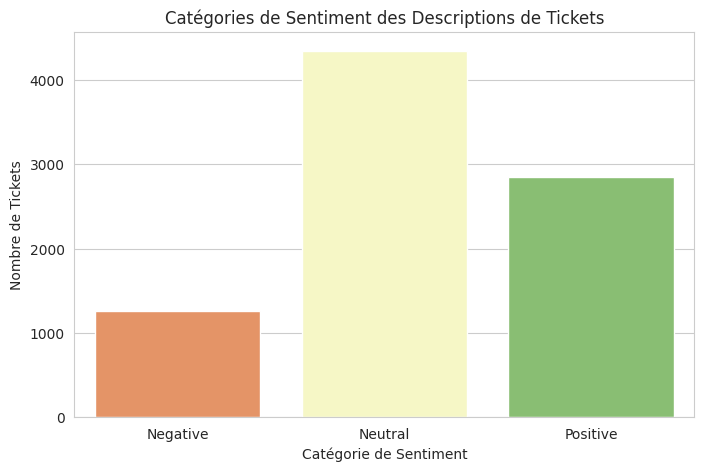

Insight: Une proportion significative de tickets a un sentiment négatif, ce qui est cohérent avec des problèmes clients.

Analyse des données non structurées terminée.


In [12]:
# 4. Analyse Exploratoire de Base et Sentiment Analysis
print("\n4. Analyse Exploratoire de Base et Sentiment Analysis...")

# Distribution des types de tickets
print("\nDistribution des types de tickets:")
plt.figure(figsize=(10, 6))
sns.countplot(y='Ticket Type', data=tickets_df, order=tickets_df['Ticket Type'].value_counts().index, palette='viridis')
plt.title('Distribution des Types de Tickets Support')
plt.xlabel('Nombre de Tickets')
plt.ylabel('Type de Ticket')
plt.show()
print("Insight: 'Technical issue' et 'Product inquiry' sont les types de tickets les plus fréquents.")

# Distribution des sujets de tickets
print("\nDistribution des sujets de tickets (Top 10):")
plt.figure(figsize=(10, 6))
sns.countplot(y='Ticket Subject', data=tickets_df, order=tickets_df['Ticket Subject'].value_counts().nlargest(10).index, palette='plasma')
plt.title('Top 10 Sujets de Tickets Support')
plt.xlabel('Nombre de Tickets')
plt.ylabel('Sujet du Ticket')
plt.show()
print("Insight: 'Account access', 'Product setup', 'Network problem' sont les sujets récurrents.")

# Analyse de Sentiment sur 'Ticket Description'
# Fonction pour nettoyer le texte (supprimer la ponctuation et convertir en minuscules)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text) # Supprimer le texte entre crochets
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Supprimer les URLs
    text = re.sub(r'<.*?>+', '', text) # Supprimer les balises HTML
    text = re.sub(r'[%s]' % re.escape(r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), '', text) # Supprimer la ponctuation
    text = re.sub(r'\n', ' ', text) # Remplacer les retours à la ligne par des espaces
    text = re.sub(r'\w*\d\w*', '', text) # Supprimer les mots contenant des chiffres
    return text

tickets_df['Cleaned_Description'] = tickets_df['Ticket Description'].apply(clean_text)

# Fonction pour obtenir le sentiment (polarité)
def get_sentiment(text):
    if text: # Assurez-vous que le texte n'est pas vide
        return TextBlob(text).sentiment.polarity
    return 0.0 # Neutre si le texte est vide

tickets_df['Sentiment_Polarity'] = tickets_df['Cleaned_Description'].apply(get_sentiment)

print("\nDistribution de la polarité de sentiment des descriptions de tickets:")
plt.figure(figsize=(10, 6))
sns.histplot(tickets_df['Sentiment_Polarity'], bins=30, kde=True)
plt.title('Distribution de la Polarité de Sentiment des Descriptions de Tickets')
plt.xlabel('Polarité de Sentiment (-1: Négatif, 0: Neutre, 1: Positif)')
plt.ylabel('Nombre de Tickets')
plt.show()
print("Insight: La distribution de sentiment est centrée autour de 0, indiquant une majorité de descriptions neutres.")
print("Cependant, il y a des queues vers les sentiments négatifs, ce qui est attendu pour des tickets de support.")

# Classer le sentiment en catégories
def classify_sentiment(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

tickets_df['Sentiment_Category'] = tickets_df['Sentiment_Polarity'].apply(classify_sentiment)

print("\nDistribution des catégories de sentiment:")
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment_Category', data=tickets_df, order=['Negative', 'Neutral', 'Positive'], palette='RdYlGn')
plt.title('Catégories de Sentiment des Descriptions de Tickets')
plt.xlabel('Catégorie de Sentiment')
plt.ylabel('Nombre de Tickets')
plt.show()
print("Insight: Une proportion significative de tickets a un sentiment négatif, ce qui est cohérent avec des problèmes clients.")

print("\nAnalyse des données non structurées terminée.")

**Analyse Comparative des Données Structurées et Non Structurées**


Cet exercice a mis en lumière les différences fondamentales dans le traitement et l'analyse des données structurées (ventes de produits) et non structurées (tickets de support client).

1. Données Structurées (Dataset de Ventes - statsfinal.csv)
Caractéristiques :

* Format fixe et prédéfini : organisé en lignes et colonnes avec des types de données clairs (dates, nombres entiers/flottants).

* Facilement interrogeable : les relations entre les colonnes sont explicites.

* Prêt pour l'analyse quantitative : directement utilisable pour des calculs statistiques, des agrégations et des visualisations standard.


Défis rencontrés :

* Nettoyage minimal : pour statsfinal.csv, les défis étaient minimes. Il a fallu s'assurer que la colonne d'index était correctement gérée et que la colonne 'Date' était convertie au bon format datetime. Aucune valeur manquante significative n'a été observée dans les colonnes clés.


Outils et Techniques efficaces :

* Pandas : excellent pour le chargement, l'inspection (.head(), .info(), .isnull().sum()), la conversion de types (pd.to_datetime), et les opérations d'agrégation (.groupby(), .sum(), .mean()).

* Matplotlib / Seaborn : très efficaces pour la visualisation des tendances temporelles (graphiques linéaires), des distributions (histogrammes) et des corrélations (heatmaps).

* Statistiques descriptives : .describe() pour un aperçu rapide des distributions numériques.


Insights dérivés :

* Tendances des ventes au fil du temps pour chaque produit.

* Volumes de ventes comparatifs entre différents produits.

* Corrélations entre les ventes de différents produits.

* Distributions des quantités vendues.


2. Données Non Structurées (Dataset de Tickets Support - customer_support_tickets.csv)
Caractéristiques :

* Format libre : principalement du texte libre (Ticket Description, Resolution).

* Sens et contexte implicites : le sens doit être extrait du langage naturel.

* Nécessite une interprétation : les informations ne sont pas directement quantifiables sans traitement.


Défis rencontrés :

* Nettoyage du texte : les descriptions des tickets peuvent contenir des fautes de frappe, des abréviations, de la ponctuation, des retours à la ligne, des URLs ou d'autres caractères spéciaux qui doivent être normalisés ou supprimés avant l'analyse.

* Extraction de sens : la tâche principale est de transformer le texte en informations exploitables (par exemple, identifier le sentiment, les mots-clés fréquents, les sujets). Cela ne peut pas être fait avec de simples agrégations numériques.

* Subjectivité : l'interprétation du sentiment ou du sujet peut être subjective et dépendre de l'outil ou de la technique utilisée.

* Dépendances externes : nécessite des bibliothèques NLP spécifiques (comme TextBlob ou NLTK, spaCy, transformers) qui ne sont pas toujours installées par défaut.


Outils et Techniques efficaces :

* Pandas : pour le chargement, l'inspection de base et l'application de fonctions de nettoyage/analyse de texte à des colonnes entières.

* Expressions régulières (re) : essentielles pour le nettoyage de texte (supprimer la ponctuation, les URLs, les caractères indésirables).

* TextBlob : outil simple et efficace pour l'analyse de sentiment (polarité et subjectivité). Il est facile à utiliser pour une première passe sur le sentiment.

* Matplotlib / Seaborn : pour visualiser les distributions des catégories de tickets et des sentiments.

* Comptage de fréquences : Pour identifier les types et sujets de tickets les plus courants.


Insights dérivés :

* Types et sujets de problèmes les plus fréquents rencontrés par les clients.

* Distribution générale du sentiment des clients (majoritairement neutre, mais avec une queue négative significative pour les problèmes).

* Identification des domaines où les clients expriment le plus de frustration ou de satisfaction.


3. Conclusion

Les données structurées sont directes et permettent des analyses quantitatives précises sur les performances et les tendances. Elles répondent aux questions "quoi" et "combien".

Les données non structurées, bien que plus difficiles à traiter, sont cruciales pour comprendre le "pourquoi" et le "comment". Elles fournissent un aperçu direct de la voix du client, de ses frustrations, de ses besoins et de ses expériences.

Une analyse complète et holistique des opérations d'une entreprise nécessite souvent l'intégration et la comparaison d'insights provenant des deux types de données. Par exemple, des ventes en baisse (données structurées) pourraient être expliquées par un sentiment client négatif récurrent sur un produit spécifique (données non structurées).

**Exercice 2: Conversion de Données Non Structurées en Structurées**


In [13]:
import pandas as pd
import re # Pour les expressions régulières
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter # Pour compter les éléments fréquents

# Configurer le style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

print("--- Exercice 2: Conversion de Données Non Structurées en Structurées ---")

--- Exercice 2: Conversion de Données Non Structurées en Structurées ---


In [14]:
# 1. Chargement du dataset de tweets
print("\n1. Chargement du dataset 'Tweets.csv'...")
csv_path = 'Tweets.csv'

try:
    df = pd.read_csv(csv_path)
    print(f"Dataset '{csv_path}' chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier '{csv_path}' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est dans le même répertoire.")
    exit()


1. Chargement du dataset 'Tweets.csv'...
Dataset 'Tweets.csv' chargé avec succès.


In [15]:
# 2. Afficher les premières lignes pour comprendre sa structure
print("\n2. Premières lignes du dataset original:")
print(df.head())

print("\nInformations de base sur le dataset original:")
df.info()

print("\nValeurs manquantes dans le dataset original:")
print(df.isnull().sum())

# Nettoyage initial: Remplir les valeurs manquantes dans 'text' et 'selected_text' avec des chaînes vides
df['text'] = df['text'].fillna('')
df['selected_text'] = df['selected_text'].fillna('')


2. Premières lignes du dataset original:
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  

Informations de base sur le dataset original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0

In [16]:

# 3. Extraction d'informations clés (hashtags et mentions)
print("\n3. Extraction des hashtags et mentions du texte des tweets...")

# Fonction pour extraire les hashtags
def extract_hashtags(text):
    # Regex pour trouver les mots précédés de '#'
    hashtags = re.findall(r'#(\w+)', text)
    return hashtags

# Fonction pour extraire les mentions
def extract_mentions(text):
    # Regex pour trouver les mots précédés de '@'
    mentions = re.findall(r'@(\w+)', text)
    return mentions

# Appliquer les fonctions pour créer de nouvelles colonnes
df['hashtags'] = df['text'].apply(extract_hashtags)
df['mentions'] = df['text'].apply(extract_mentions)


3. Extraction des hashtags et mentions du texte des tweets...


In [17]:
# 4. Organiser l'information extraite dans un format structuré (DataFrame)
# Les colonnes 'hashtags' et 'mentions' sont déjà des listes, ce qui est un format structuré.
# Le DataFrame df lui-même est maintenant plus structuré.
print("\n4. Aperçu du DataFrame avec les nouvelles colonnes 'hashtags' et 'mentions':")
print(df.head())


4. Aperçu du DataFrame avec les nouvelles colonnes 'hashtags' et 'mentions':
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment hashtags mentions  
0  I`d have responded, if I were going   neutral       []       []  
1                             Sooo SAD  negative       []       []  
2                          bullying me  negative       []       []  
3                       leave me alone  negative       []       []  
4                        Sons of ****,  negative       []       []  



5.1 Analyse de la distribution du sentiment:


/tmp/ipython-input-18-1439570660.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis', order=df['sentiment'].value_counts().index)


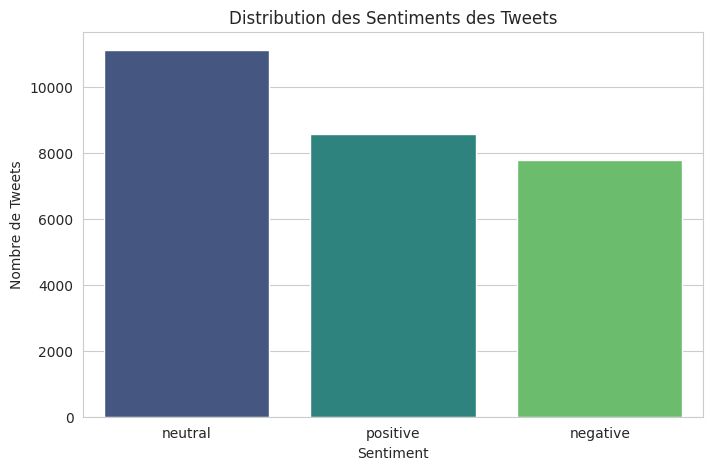

Insight: Le sentiment 'neutral' est le plus fréquent, suivi par 'positive' et 'negative'.


In [18]:
# 5. Analyse de base sur les données nouvellement structurées

# 5.1 Distribution du sentiment (déjà présente, mais re-visualisons)
print("\n5.1 Analyse de la distribution du sentiment:")
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis', order=df['sentiment'].value_counts().index)
plt.title('Distribution des Sentiments des Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Nombre de Tweets')
plt.show()
print("Insight: Le sentiment 'neutral' est le plus fréquent, suivi par 'positive' et 'negative'.")


5.2 Analyse des hashtags les plus fréquents:


/tmp/ipython-input-19-1083388275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Hashtag', data=top_hashtags, palette='mako')


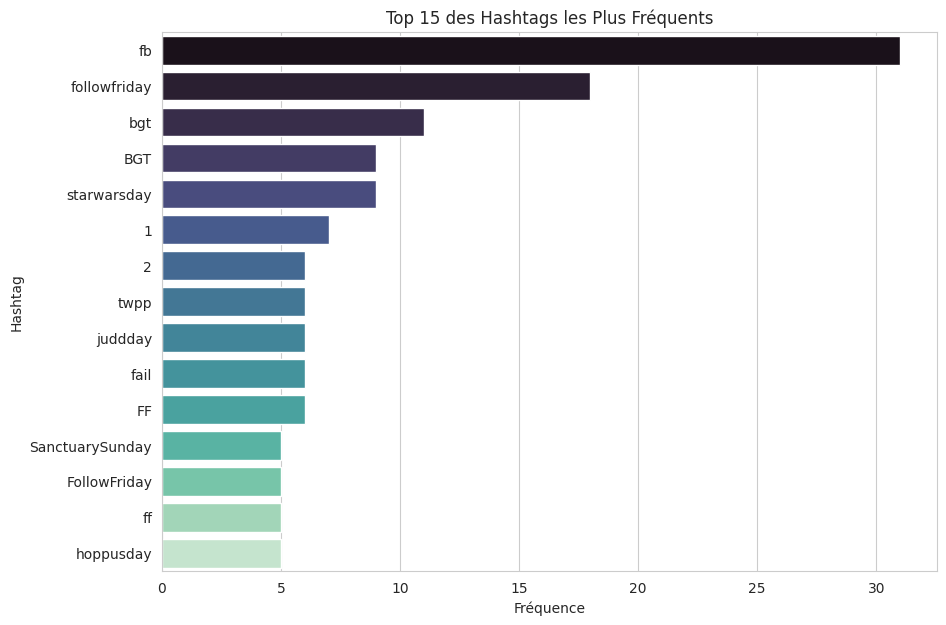

Insight: Identification des sujets et campagnes populaires via les hashtags.


In [19]:
# 5.2 Analyse des hashtags les plus fréquents
print("\n5.2 Analyse des hashtags les plus fréquents:")
all_hashtags = [tag for sublist in df['hashtags'] for tag in sublist]
hashtag_counts = Counter(all_hashtags)
top_hashtags = pd.DataFrame(hashtag_counts.most_common(15), columns=['Hashtag', 'Count'])

if not top_hashtags.empty:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Count', y='Hashtag', data=top_hashtags, palette='mako')
    plt.title('Top 15 des Hashtags les Plus Fréquents')
    plt.xlabel('Fréquence')
    plt.ylabel('Hashtag')
    plt.show()
    print("Insight: Identification des sujets et campagnes populaires via les hashtags.")
else:
    print("Aucun hashtag trouvé pour l'analyse.")


5.3 Analyse des mentions les plus fréquentes:


/tmp/ipython-input-20-3124336615.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Mention', data=top_mentions, palette='rocket')


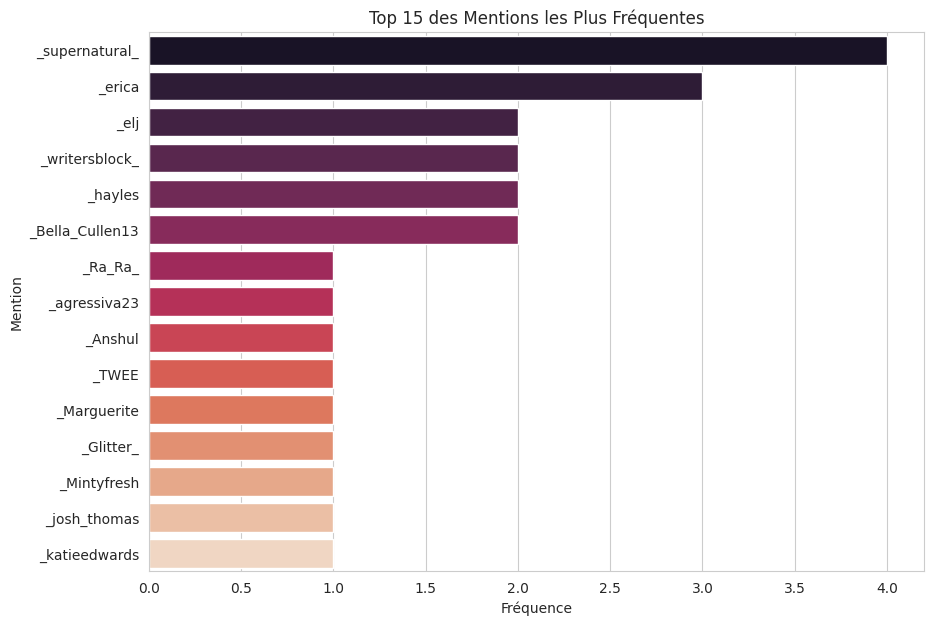

Insight: Identification des utilisateurs ou entités les plus souvent cités/interagis.

Conversion et analyse des données de tweets terminées.


In [20]:
# 5.3 Analyse des mentions les plus fréquentes
print("\n5.3 Analyse des mentions les plus fréquentes:")
all_mentions = [mention for sublist in df['mentions'] for mention in sublist]
mention_counts = Counter(all_mentions)
top_mentions = pd.DataFrame(mention_counts.most_common(15), columns=['Mention', 'Count'])

if not top_mentions.empty:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Count', y='Mention', data=top_mentions, palette='rocket')
    plt.title('Top 15 des Mentions les Plus Fréquentes')
    plt.xlabel('Fréquence')
    plt.ylabel('Mention')
    plt.show()
    print("Insight: Identification des utilisateurs ou entités les plus souvent cités/interagis.")
else:
    print("Aucune mention trouvée pour l'analyse.")

print("\nConversion et analyse des données de tweets terminées.")


**Analyse Comparative : Données Tweets Structurées vs. Non Structurées**


Cet exercice a illustré le processus de transformation de données textuelles non structurées (tweets) en un format plus structuré, et comment cela facilite l'analyse et la génération d'insights.

1. Défis rencontrés lors du traitement des données non structurées

Le dataset Tweets.csv contient une colonne text qui est la principale source de données non structurées. Les défis rencontrés pour la traiter incluent :

* Variabilité du Langage : les tweets sont des textes courts, informels, avec de l'argot, des abréviations, des fautes de frappe, et un usage créatif de la ponctuation et des symboles.

* Extraction d'Entités Spécifiques : identifier et isoler des éléments comme les hashtags (#) et les mentions (@) nécessite des techniques de reconnaissance de motifs, comme les expressions régulières, plutôt que de simples accès par colonne.

* Bruit : les URLs, les caractères spéciaux non pertinents, et les retours à la ligne peuvent polluer le texte et doivent être nettoyés avant l'analyse.

* Ambiguïté : le sens du texte peut être ambigu, et l'analyse de sentiment, bien que facilitée par la colonne sentiment préexistante, peut être complexe si elle devait être dérivée du texte brut.


2. Outils et Techniques efficaces pour chaque type de données

* Pour le chargement et la manipulation de base (commun aux deux) :

> Pandas : indispensable pour charger le fichier CSV (pd.read_csv), inspecter le DataFrame (.head(), .info(), .isnull().sum()), et manipuler les colonnes (remplir les NaN, appliquer des fonctions).


* Pour le traitement des données non structurées (texte) :

> Expressions Régulières (re) : extrêmement efficaces pour la reconnaissance de motifs spécifiques dans le texte, comme l'extraction des hashtags (#\w+) et des mentions (@\w+). Elles permettent de "structurer" ces éléments du texte libre.

> apply() de Pandas : permet d'appliquer une fonction personnalisée (ici, nos fonctions d'extraction) à chaque élément d'une colonne de texte, créant ainsi de nouvelles colonnes structurées.

> collections.Counter : très utile pour compter la fréquence des éléments extraits (hashtags, mentions) et identifier les plus courants.

> TextBlob (pour l'analyse de sentiment si non pré-existante) : bien que le sentiment soit une colonne donnée, si nous devions l'extraire du text brut, TextBlob (ou des modèles NLP plus avancés) serait l'outil pour obtenir la polarité et la subjectivité.


* Pour l'analyse et la visualisation des données structurées (après extraction) :

Pandas : Pour l'agrégation et le tri des fréquences (ex: top_hashtags = pd.DataFrame(hashtag_counts.most_common(15), ...) ).

Matplotlib / Seaborn : Essentiels pour visualiser les distributions (countplot pour le sentiment) et les fréquences (barplot pour les top hashtags/mentions), rendant les insights immédiatement compréhensibles.


3. Comparaison des insights avec le format original non structuré

Insights de l'original (non structuré : colonne text brute) :

* Sans traitement, le texte brut est difficile à analyser à grande échelle. On peut lire quelques tweets pour avoir une idée qualitative, mais il est impossible de quantifier des tendances ou des relations.

* Le sentiment est donné (colonne sentiment), mais on ne sait pas pourquoi ce sentiment est là sans lire le texte.

* On ne peut pas facilement identifier les sujets dominants ou les entités les plus discutées sans des outils NLP.


Insights du nouveau format structuré (avec colonnes hashtags, mentions, sentiment) :

La structuration des données non structurées a permis des analyses beaucoup plus profondes et quantifiables :

* Distribution des Sentiments : la visualisation du sentiment (déjà structuré) confirme la prédominance des tweets neutres, avec une part significative de positifs et négatifs.

* Tendances Thématiques (hashtags) : permet maintenant d'identifier les sujets les plus discutés ou les campagnes populaires en analysant les hashtags les plus fréquents. Cela donne un aperçu direct des "tendances" au sein du corpus de tweets.

* Influence et Interactions (mentions) : l'analyse des mentions révèle les utilisateurs ou entités les plus fréquemment interpellés ou discutés, ce qui peut indiquer des influenceurs, des marques populaires, ou des points de contact clés.

£* Analyse Combinée : avec les données structurées, il est désormais possible de croiser les informations. Par exemple, on pourrait analyser le sentiment moyen associé à un hashtag particulier ou à une mention spécifique. Cela permet de comprendre non seulement ce qui est discuté, mais aussi comment c'est perçu.


**Conclusion :**

La conversion de données non structurées en données structurées est une étape fondamentale en science des données. Elle transforme le texte libre, difficilement analysable à grande échelle, en des attributs quantifiables et catégorisables. Cela permet d'appliquer des techniques d'analyse statistique et de visualisation standard, révélant des motifs, des tendances et des relations qui seraient invisibles dans le format brut. Bien que le processus de structuration puisse être complexe et nécessiter des outils NLP avancés, les insights gagnés en valent la peine pour une compréhension plus approfondie des données.